# Tips 데이터 다중선형회귀

## 분석 목표

`seaborn`의 `tips` 데이터를 사용하여 `tip`을 예측하는 다중선형회귀를 준비한다.

이번 단계에서는 독립 변수를 아직 확정하지 않고, 다음 분석까지만 수행한다.

1. 라이브러리와 데이터 로딩
2. 데이터 구조 및 결측치 확인
3. 학습 데이터와 테스트 데이터 분리
4. 범주형 변수와 `tip`의 eta squared 분석
5. 범주형 변수별 `tip` boxplot 분석
6. 수치형 변수와 `tip`의 상관계수 및 산점도 분석

분석 결과를 확인한 뒤 독립 변수를 선정하고, 이후 전처리와 Keras 모델을 작성한다.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import koreanize_matplotlib
except ImportError:
    pass

sns.set_theme(style="whitegrid")
tips = sns.load_dataset("tips")

print(f"Python 환경: {__import__('sys').executable}")
print(f"데이터 크기: {tips.shape}")
tips.head()

Python 환경: /workspaces/deeplearning/.venv/bin/python
데이터 크기: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. 데이터 구조와 결측치 확인

타깃 후보는 `tip`이며, 현재 단계에서는 독립 변수를 확정하지 않는다.

In [2]:
print(tips.info())
print("\n결측치 수:")
display(tips.isna().sum().to_frame("missing"))
print("\n기술통계:")
display(tips.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None

결측치 수:


,missing
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0



기술통계:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
total_bill,244.0,NaN,NaN,NaN,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,NaN,NaN,NaN,2.998279,1.383638,1.0,2.0,2.9,3.5625,10.0
sex,244,2,Male,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoker,244,2,No,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,244,4,Sat,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,244,2,Dinner,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,244.0,NaN,NaN,NaN,2.569672,0.9511,1.0,2.0,2.0,3.0,6.0


## 3. 학습 데이터와 테스트 데이터 분리

변수 선정에 사용하는 통계량은 학습 데이터에서만 계산한다. 테스트 데이터는 최종 평가 단계에서 사용하기 위해 보관한다.

In [3]:
random_state = 42
train_tips = tips.sample(frac=0.8, random_state=random_state)
test_tips = tips.drop(train_tips.index)

print(f"학습 데이터: {train_tips.shape}")
print(f"테스트 데이터: {test_tips.shape}")

학습 데이터: (195, 7)
테스트 데이터: (49, 7)


## 4. 범주형 변수의 eta squared 분석

eta squared는 범주형 변수의 그룹 차이가 `tip`의 전체 변동을 얼마나 설명하는지 나타낸다.

$$
\\eta^2 = \\frac{\\sum_g n_g(\\bar{y}_g-\\bar{y})^2}{\\sum_i(y_i-\\bar{y})^2}
$$

In [4]:
def eta_squared(data, category_column, target_column):
    overall_mean = data[target_column].mean()
    grouped = data.groupby(category_column, observed=True)[target_column].agg(["count", "mean"])
    between_group_sum = (
        grouped["count"] * (grouped["mean"] - overall_mean).pow(2)
    ).sum()
    total_sum = (data[target_column] - overall_mean).pow(2).sum()
    return between_group_sum / total_sum if total_sum else np.nan

categorical_columns = ["sex", "smoker", "day", "time"]
eta_results = pd.DataFrame(
    {
        "variable": categorical_columns,
        "eta_squared": [
            eta_squared(train_tips, column, "tip")
            for column in categorical_columns
        ],
    }
).sort_values("eta_squared", ascending=False, ignore_index=True)

eta_results

,variable,eta_squared
0,day,0.019098
1,time,0.016875
2,sex,0.007700
3,smoker,0.002062


## 5. 범주형 변수별 `tip` boxplot

boxplot으로 그룹별 중앙값, 사분위 범위, 분포 차이 및 이상치를 확인한다. 시각적 차이와 eta squared 결과를 함께 검토한 뒤 독립 변수를 선정한다.

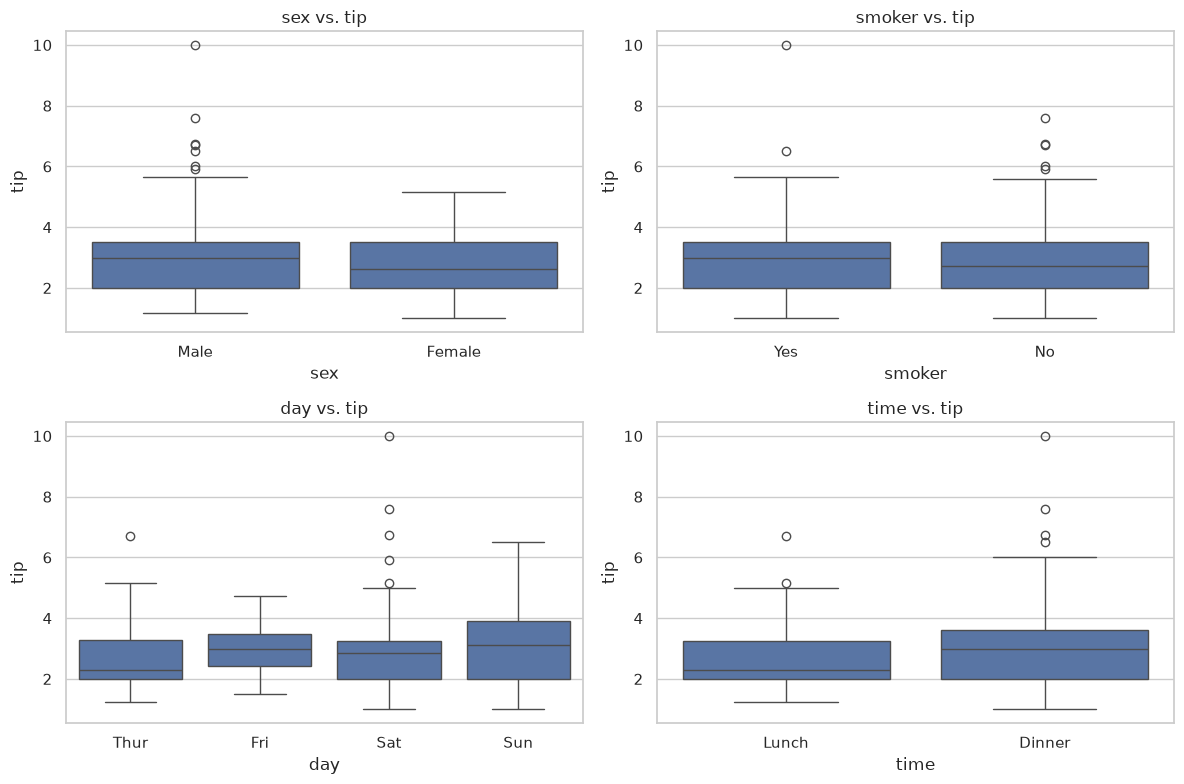

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for axis, column in zip(axes.ravel(), categorical_columns):
    sns.boxplot(data=train_tips, x=column, y="tip", ax=axis)
    axis.set_title(f"{column} vs. tip")
    axis.set_xlabel(column)
    axis.set_ylabel("tip")

plt.tight_layout()
plt.show()

## 6. 수치형 변수 분석

수치형 후보 변수의 상관계수와 산점도를 확인한다. 이 단계에서는 분석 결과만 확인하고 독립 변수는 아직 확정하지 않는다.

수치형 변수와 tip의 상관계수:


,correlation_with_tip
total_bill,0.702602
size,0.526017


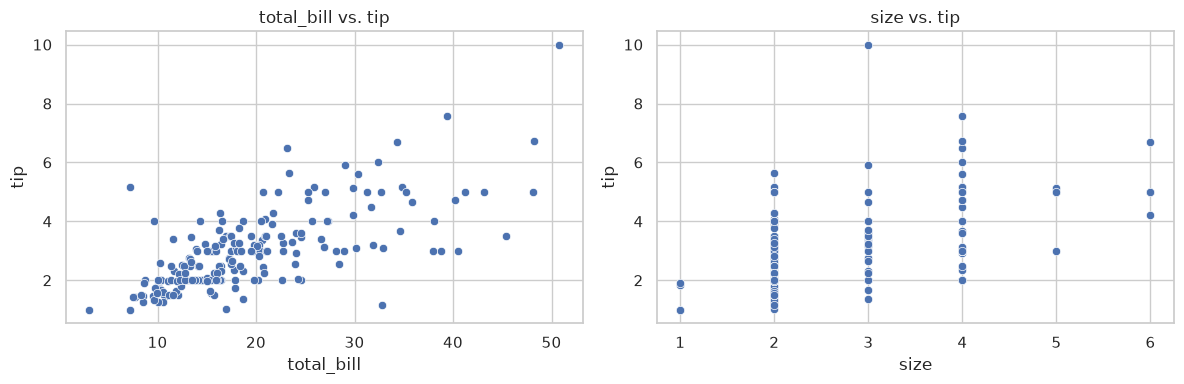

In [8]:
numeric_columns = ["total_bill", "size"]
correlation_results = (
    train_tips[numeric_columns + ["tip"]]
    .corr(numeric_only=True)["tip"]
    .drop("tip")
    .sort_values(key=np.abs, ascending=False)
    .rename("correlation_with_tip")
    .to_frame()
)

print("수치형 변수와 tip의 상관계수:")
display(correlation_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for axis, column in zip(axes, numeric_columns):
    sns.scatterplot(data=train_tips, x=column, y="tip", ax=axis)
    axis.set_title(f"{column} vs. tip")

plt.tight_layout()
plt.show()

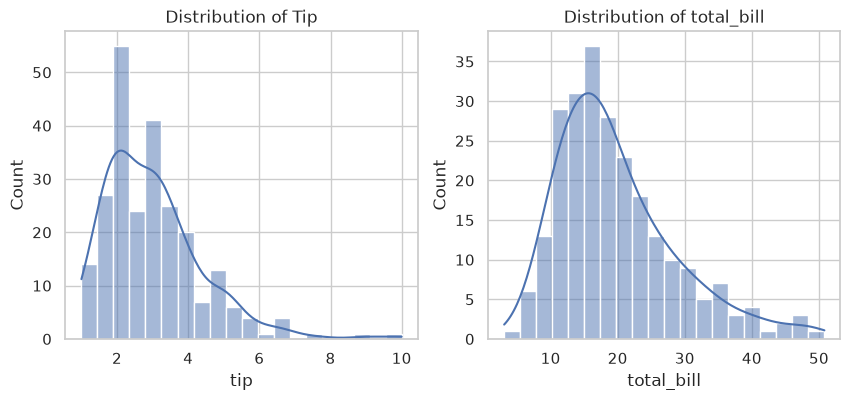

In [8]:
# tip의 정규분포 차트
# 정규분포라면 종 모양의 대칭형 곡선이 그려져야 하나, 
# 팁 데이터는 오른쪽으로 꼬리가 긴(Right-skewed) 형태가 나타남.

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
sns.histplot(tips['tip'], kde=True, bins=20)
plt.title("Distribution of Tip")

plt.subplot(1,2,2)
sns.histplot(tips['total_bill'], kde=True, bins=20)
plt.title("Distribution of total_bill")
plt.show()

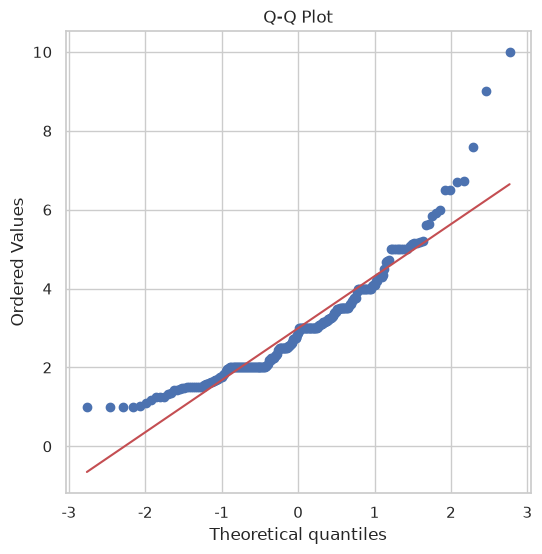

In [ ]:
# Q-Q Plot (Quantile-Quantile Plot)
'''해석: 데이터 포인트들이 빨간색 대각선 위에 정확히 일치할수록 
정규분포에 가깝다.
팁 데이터의 경우, 양쪽 끝(특히 오른쪽 끝)에서 빨간 선을 
크게 벗어나는 형태가 나타나므로 이는 데이터가 정규분포가 아니라는 
강한 증거.'''
import scipy.stats as stats

plt.figure(figsize=(6, 6))
stats.probplot(tips['tip'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [5]:
# 통계적 검정 (Shapiro-Wilk Test)
from scipy.stats import shapiro

stat, p = shapiro(tips['tip'])
print(f"Statistics={stat:.3f}, p-value={p:.3f}")

if p > 0.05:
    print("정규분포를 따름 (귀무가설 기각 실패)")
else:
    print("정규분포를 따르지 않음 (귀무가설 기각)")

Statistics=0.898, p-value=0.000
정규분포를 따르지 않음 (귀무가설 기각)


## 7. 독립 변수 선정

eta squared와 boxplot 분석 결과를 반영하여 범주형 변수는 `day`만 사용한다. 수치형 변수는 상관관계가 확인된 `total_bill`과 `size`를 사용한다.

- 수치형 변수: `total_bill`, `size`
- 범주형 변수: `day`
- 타깃 변수: `tip`

In [9]:
selected_numeric = ["total_bill", "size"]
selected_categorical = ["day"]
target_column = "tip"

print("선정된 수치형 변수:", selected_numeric)
print("선정된 범주형 변수:", selected_categorical)
print("타깃 변수:", target_column)

선정된 수치형 변수: ['total_bill', 'size']
선정된 범주형 변수: ['day']
타깃 변수: tip


## 8. 전처리

수치형 변수는 학습 데이터의 평균과 표준편차로 표준화하고, `day`는 학습 데이터의 범주를 기준으로 원-핫 인코딩한다. 테스트 데이터에는 학습 데이터에서 계산한 기준을 그대로 적용한다.

In [10]:
numeric_mean = train_tips[selected_numeric].mean()
numeric_std = train_tips[selected_numeric].std().replace(0, 1)

X_train_numeric = (train_tips[selected_numeric] - numeric_mean) / numeric_std
X_test_numeric = (test_tips[selected_numeric] - numeric_mean) / numeric_std

X_train_day = pd.get_dummies(
    train_tips[selected_categorical],
    columns=selected_categorical,
    dtype=float,
)
X_test_day = pd.get_dummies(
    test_tips[selected_categorical],
    columns=selected_categorical,
    dtype=float,
).reindex(columns=X_train_day.columns, fill_value=0.0)

X_train = pd.concat([X_train_numeric, X_train_day], axis=1).astype("float32")
X_test = pd.concat([X_test_numeric, X_test_day], axis=1).astype("float32")
y_train = train_tips[target_column].to_numpy(dtype="float32")
y_test = test_tips[target_column].to_numpy(dtype="float32")

print("입력 특성:", list(X_train.columns))
print("학습 입력 크기:", X_train.shape)
print("테스트 입력 크기:", X_test.shape)

입력 특성: ['total_bill', 'size', 'day_Thur', 'day_Fri', 'day_Sat', 'day_Sun']
학습 입력 크기: (195, 6)
테스트 입력 크기: (49, 6)


## 9. Keras 다중선형회귀 모델 생성

여러 입력 특성을 하나의 선형 출력값으로 연결하는 `Dense(1)` 모델을 사용한다.

In [11]:
import tensorflow as tf

np.random.seed(random_state)
tf.random.set_seed(random_state)

model = tf.keras.Sequential(
    [
        tf.keras.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(1, activation="linear"),
    ]
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae", "mse"],
)

model.summary()

I0000 00:00:1790150539.762684   18456 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790150540.968272   18456 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790150549.884066   18456 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1790150553.354499   18456 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

## 10. 모델 학습

학습 데이터 일부를 검증 데이터로 사용하고, 검증 손실이 개선되지 않으면 조기 종료한다.

학습 반복 횟수: 164


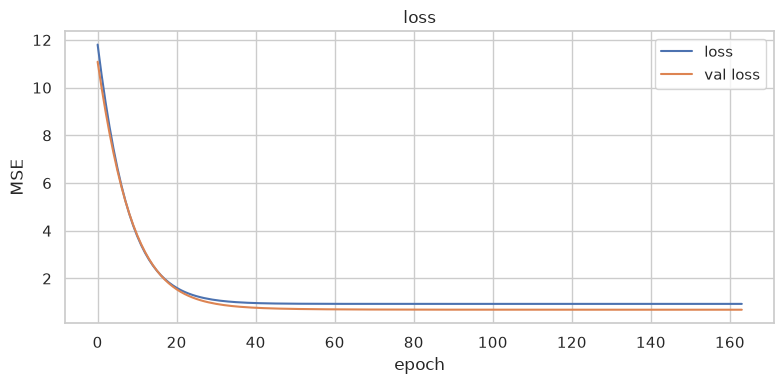

In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=0,
)

print(f"학습 반복 횟수: {len(history.history['loss'])}")

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("loss")
plt.legend()
plt.tight_layout()
plt.show()

## 11. 테스트 데이터 평가

테스트 데이터의 MSE, MAE, RMSE와 결정계수 $R^2$를 계산한다.

In [13]:
evaluation = model.evaluate(X_test, y_test, verbose=0, return_dict=True)
predictions = model.predict(X_test, verbose=0).reshape(-1)

residuals = y_test - predictions
mse = np.mean(residuals**2)
mae = np.mean(np.abs(residuals))
rmse = np.sqrt(mse)
total_sum_of_squares = np.sum((y_test - y_test.mean()) ** 2)
r_squared = 1 - np.sum(residuals**2) / total_sum_of_squares

metrics = pd.DataFrame(
    {
        "metric": ["loss_mse", "mae", "mse", "rmse", "r_squared"],
        "value": [evaluation["loss"], mae, mse, rmse, r_squared],
    }
)

display(metrics)
display(
    pd.DataFrame(
        {
            "actual_tip": y_test,
            "predicted_tip": predictions,
            "residual": residuals,
        }
    ).head(10)
)

,metric,value
0,loss_mse,1.541209
1,mae,0.945958
2,mse,1.541209
3,rmse,1.241454
4,r_squared,0.339363


,actual_tip,predicted_tip,residual
0,1.66,2.249785,-0.589785
1,3.02,2.543886,0.476114
2,4.08,2.729791,1.350209
3,2.75,2.958985,-0.208985
4,3.07,2.774161,0.295839
5,2.05,4.010803,-1.960803
6,2.50,2.322429,0.177571
7,5.20,4.756292,0.443707
8,4.34,3.861761,0.478240
9,1.50,3.550826,-2.050826


## 12. 예측값과 잔차 분석

실제 `tip`과 예측값을 비교하고, 잔차에 패턴이 남아 있는지 확인한다.

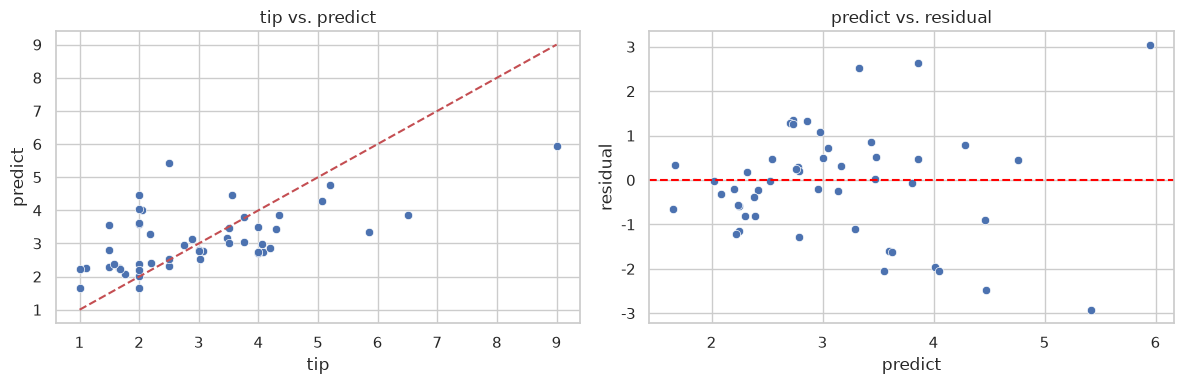

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x=y_test, y=predictions, ax=axes[0])
minimum = min(y_test.min(), predictions.min())
maximum = max(y_test.max(), predictions.max())
axes[0].plot([minimum, maximum], [minimum, maximum], "r--")
axes[0].set_xlabel("tip")
axes[0].set_ylabel("predict")
axes[0].set_title("tip vs. predict")

sns.scatterplot(x=predictions, y=residuals, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("predict")
axes[1].set_ylabel("residual")
axes[1].set_title("predict vs. residual")

plt.tight_layout()
plt.show()